In [38]:
import numpy as np
import seaborn as sb
import pandas as pd

In [37]:
# A simple dataset with missing values
data = {"Name": ["Alice", "Bob", "Charlie", "Diana", "Eve"],
"Age":[25,np.nan, 30, 22, np.nan],
"Score":[88.5, 73.0, np.nan, 91.0, 65.5],
"City":["NYC", "LA", None, "Chicago", "NYC"]}
df = pd.DataFrame(data)
df

,Name,Age,Score,City
0,Alice,25.0,88.5,NYC
1,Bob,NaN,73.0,LA
2,Charlie,30.0,NaN,NaN
3,Diana,22.0,91.0,Chicago
4,Eve,NaN,65.5,NYC


In [38]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5 entries, 0 to 4
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Name    5 non-null      str    
 1   Age     3 non-null      float64
 2   Score   4 non-null      float64
 3   City    4 non-null      str    
dtypes: float64(2), str(2)
memory usage: 292.0 bytes


In [39]:
df.isna()

,Name,Age,Score,City
0,False,False,False,False
1,False,True,False,False
2,False,False,True,True
3,False,False,False,False
4,False,True,False,False


In [19]:
#The first sum will give the sum of null values in couln wise split, the next one will sum all the values from column-wise split.
df.isna().sum().sum()

np.int64(4)

In [20]:
df.notna()

,Name,Age,Score,City
0,True,True,True,True
1,True,False,True,True
2,True,True,False,False
3,True,True,True,True
4,True,False,True,True


In [21]:
#The first sum will give the sum of not null values in couln wise split, the next one will sum all the values from column-wise split.
df.notna().sum().sum()

np.int64(16)

In [23]:
#This will drop the rows where the null values are present.
df_dropped = df.dropna()
df_dropped

,Name,Age,Score,City
0,Alice,125.0,88.5,NYC
3,Diana,22.0,91.0,Chicago


In [26]:
#This will drop the rows where the null values are present in thecolumns mentioned in subset.
df_dropped = df.dropna(subset=['Age','City'])
df_dropped

,Name,Age,Score,City
0,Alice,125.0,88.5,NYC
3,Diana,22.0,91.0,Chicago


In [27]:
#This will be used to drop the columns(axis=1) where atlease 1 value is null.
df_dropped = df.dropna(axis=1)
df_dropped

,Name
0,Alice
1,Bob
2,Charlie
3,Diana
4,Eve


### when to use dropna()
1. When my data contains less than 5% of null values
2. If we have enough data even after dropping data
3. If there is a pattern for null values, i.e, eg: there is a null value for every 3 rows.
4. 
It is always advised to not use inplace=True while used dropna

In [29]:
dfCleanednullVal = df.fillna('no value')
dfCleanednullVal

,Name,Age,Score,City
0,Alice,125.0,88.5,NYC
1,Bob,no value,73.0,LA
2,Charlie,30.0,no value,no value
3,Diana,22.0,91.0,Chicago
4,Eve,no value,65.5,NYC


In [31]:
dfCleanednullVal = df.fillna({'Name':'John Doe','Age':0,'Score':0,'City':'No here'})
dfCleanednullVal

,Name,Age,Score,City
0,Alice,125.0,88.5,NYC
1,Bob,0.0,73.0,LA
2,Charlie,30.0,0.0,No here
3,Diana,22.0,91.0,Chicago
4,Eve,0.0,65.5,NYC


In [43]:
#But setting the null values should not be done random, like no random value shoul be provided. So, in such cases, if the column is
# numeric, then calculate the mean of the columnn and update. This is known as MEAN IMPUTATION.
ageMean=df['Age'].mean()
print(f"Mean: {ageMean:.2f}")
dfCleanednullVal = df.fillna({'Name':'John Doe','Age':round(df['Age'].mean(),2),'Score':0,'City':'No here'})
dfCleanednullVal

Mean: 25.67


,Name,Age,Score,City
0,Alice,25.00,88.5,NYC
1,Bob,25.67,73.0,LA
2,Charlie,30.00,0.0,No here
3,Diana,22.00,91.0,Chicago
4,Eve,25.67,65.5,NYC


In [56]:
# For columns like cities we can replace the nulll values with most common city.
commonCities =df['City'].value_counts()
print(f"commonCities: {commonCities}")
commonCity = commonCities.idxmax()
print(f"commonCity: {commonCity}")

dfCleanednullVal = df.fillna({'Name':'John Doe','Age':round(df['Age'].mean(),2),'Score':0,'City':commonCity})
dfCleanednullVal

commonCities: City
NYC        2
LA         1
Chicago    1
Name: count, dtype: int64
commonCity: NYC


,Name,Age,Score,City
0,Alice,25.00,88.5,NYC
1,Bob,25.67,73.0,LA
2,Charlie,30.00,0.0,NYC
3,Diana,22.00,91.0,Chicago
4,Eve,25.67,65.5,NYC


## FORWARD FILLING
Filling my current data according to my previous data.

In [69]:
data = {"Day":[1, 2, 3, 4, 5],"Temp":[22, np. nan, np.nan, 25, 26]}
df = pd.DataFrame(data)
df

,Day,Temp
0,1,22.0
1,2,NaN
2,3,NaN
3,4,25.0
4,5,26.0


##ffill iss forward filling, meaning for row 2 the initial value was null, now 22 because it's previous val is 22
#For 3rd row, the new value is 22 , so it's value will also be copied as 22.
dataFilled = df.ffill()
dataFilled

## BACKWORD FILLING
filling my current data with the prev value, but this will traverse from backwards

In [70]:
##bfill is backward filling, i.e, forward filling but in reverse direction, meaning for row 3 from back, the initial value was null, now
#25 because it's previous val from backwards is 25
#For 2rd row, the new value is 25 , so it's value will also be copied as 25.
dataFilled = df.bfill()
dataFilled

,Day,Temp
0,1,22.0
1,2,25.0
2,3,25.0
3,4,25.0
4,5,26.0


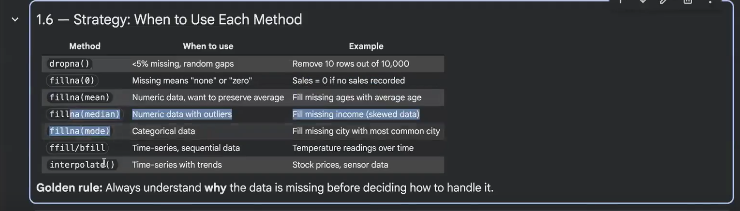

In [71]:
#This is to check the data sets available in seaborn
sb.get_dataset_names()

['anagrams',
 'anscombe',
 'attention',
 'brain_networks',
 'car_crashes',
 'diamonds',
 'dots',
 'dowjones',
 'exercise',
 'flights',
 'fmri',
 'geyser',
 'glue',
 'healthexp',
 'iris',
 'mpg',
 'penguins',
 'planets',
 'seaice',
 'taxis',
 'tips',
 'titanic']

In [39]:
taxiData = sb.load_dataset('taxis')
taxiData.info()

<class 'pandas.DataFrame'>
RangeIndex: 6433 entries, 0 to 6432
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   pickup           6433 non-null   datetime64[us]
 1   dropoff          6433 non-null   datetime64[us]
 2   passengers       6433 non-null   int64         
 3   distance         6433 non-null   float64       
 4   fare             6433 non-null   float64       
 5   tip              6433 non-null   float64       
 6   tolls            6433 non-null   float64       
 7   total            6433 non-null   float64       
 8   color            6433 non-null   str           
 9   payment          6389 non-null   str           
 10  pickup_zone      6407 non-null   str           
 11  dropoff_zone     6388 non-null   str           
 12  pickup_borough   6407 non-null   str           
 13  dropoff_borough  6388 non-null   str           
dtypes: datetime64[us](2), float64(5), int64(1), str(6)


In [104]:
taxiData.isna().sum()

pickup              0
dropoff             0
passengers          0
distance            0
fare                0
tip                 0
tolls               0
total               0
color               0
payment            44
pickup_zone         0
dropoff_zone       45
pickup_borough     26
dropoff_borough    45
dtype: int64

In [40]:
modePickUpZone = taxiData["pickup_zone"].mode()[0]
modePickUpZone

'Midtown Center'

In [41]:
#0.6 % of data is missing, so we can replace null with most repeated value, i.e, Mode
taxiData = taxiData.fillna({'pickup_zone':modePickUpZone})
taxiData.head()

,pickup,dropoff,passengers,distance,fare,tip,tolls,total,color,payment,pickup_zone,dropoff_zone,pickup_borough,dropoff_borough
0,2019-03-23 20:21:09,2019-03-23 20:27:24,1,1.60,7.0,2.15,0.0,12.95,yellow,credit card,Lenox Hill West,UN/Turtle Bay South,Manhattan,Manhattan
1,2019-03-04 16:11:55,2019-03-04 16:19:00,1,0.79,5.0,0.00,0.0,9.30,yellow,cash,Upper West Side South,Upper West Side South,Manhattan,Manhattan
2,2019-03-27 17:53:01,2019-03-27 18:00:25,1,1.37,7.5,2.36,0.0,14.16,yellow,credit card,Alphabet City,West Village,Manhattan,Manhattan
3,2019-03-10 01:23:59,2019-03-10 01:49:51,1,7.70,27.0,6.15,0.0,36.95,yellow,credit card,Hudson Sq,Yorkville West,Manhattan,Manhattan
4,2019-03-30 13:27:42,2019-03-30 13:37:14,3,2.16,9.0,1.10,0.0,13.40,yellow,credit card,Midtown East,Yorkville West,Manhattan,Manhattan


## GROUP BY
this will allow to split the data according to some criteria,  Apply various funs(sum,mean,mode etc) to the groups and combine the results into a sigle table

In [59]:
import pandas as pd

data = {
    'Department': ['IT', 'IT', 'HR', 'HR', 'Finance', 'Finance', 'IT', 'HR'],
    'Employee': ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H'],
    'Gender': ['M', 'F', 'F', 'M', 'M', 'F', 'M', 'F'],
    'Salary': [60000, 65000, 50000, 52000, 70000, 72000, 68000, 51000],
    'Experience': [3, 5, 2, 4, 6, 7, 5, 3],
    'City': ['Chennai', 'Mumbai', 'Chennai', 'Delhi', 'Mumbai', 'Delhi', 'Chennai', 'Mumbai']
}

df = pd.DataFrame(data)
df

,Department,Employee,Gender,Salary,Experience,City
0,IT,A,M,60000,3,Chennai
1,IT,B,F,65000,5,Mumbai
2,HR,C,F,50000,2,Chennai
3,HR,D,M,52000,4,Delhi
4,Finance,E,M,70000,6,Mumbai
5,Finance,F,F,72000,7,Delhi
6,IT,G,M,68000,5,Chennai
7,HR,H,F,51000,3,Mumbai


In [11]:
moneyAllocated=df.groupby('Department')['Salary'].sum()
print(moneyAllocated)

# SUM
print("Sum of Salary:\n", df.groupby('Department')['Salary'].sum(), "\n")

# MEAN
print("Average Salary:\n", df.groupby('Department')['Salary'].mean(), "\n")

# MAX
print("Max Salary:\n", df.groupby('Department')['Salary'].max(), "\n")

# MIN
print("Min Salary:\n", df.groupby('Department')['Salary'].min(), "\n")

# COUNT
print("Count:\n", df.groupby('Department')['Salary'].count(), "\n")
# MEDIAN
print("MEDEAN:\n", df.groupby('Department')['Salary'].median(), "\n")

# STD DEVIATION
print("STANDARD DEVIATION:\n", df.groupby('Department')['Salary'].std(), "\n")


Department
Finance    142000
HR         153000
IT         193000
Name: Salary, dtype: int64
Sum of Salary:
 Department
Finance    142000
HR         153000
IT         193000
Name: Salary, dtype: int64 

Average Salary:
 Department
Finance    71000.000000
HR         51000.000000
IT         64333.333333
Name: Salary, dtype: float64 

Max Salary:
 Department
Finance    72000
HR         52000
IT         68000
Name: Salary, dtype: int64 

Min Salary:
 Department
Finance    70000
HR         50000
IT         60000
Name: Salary, dtype: int64 

Count:
 Department
Finance    2
HR         3
IT         3
Name: Salary, dtype: int64 

MEDEAN:
 Department
Finance    71000.0
HR         51000.0
IT         65000.0
Name: Salary, dtype: float64 

STANDARD DEVIATION:
 Department
Finance    1414.213562
HR         1000.000000
IT         4041.451884
Name: Salary, dtype: float64 



In [12]:
#Multiple column groupby
df[(df["Department"]=='IT') & (df['Gender'] == 'F')]

,Department,Employee,Gender,Salary,Experience,City
1,IT,B,F,65000,5,Mumbai


In [22]:
#Average salary per department in terms of gender
result = df.groupby(['Department','Gender'])['Salary'].sum().reset_index()
result

,Department,Gender,Salary
0,Finance,F,72000
1,Finance,M,70000
2,HR,F,101000
3,HR,M,52000
4,IT,F,65000
5,IT,M,128000


In [35]:
grouped = df.groupby(['Department','Gender'])
for groupCriteria, dfEntry in grouped:
    print(f"groupCriteria: {groupCriteria}")
    print(dfEntry)

groupCriteria: ('Finance', 'F')
  Department Employee Gender  Salary  Experience   City
5    Finance        F      F   72000           7  Delhi
groupCriteria: ('Finance', 'M')
  Department Employee Gender  Salary  Experience    City
4    Finance        E      M   70000           6  Mumbai
groupCriteria: ('HR', 'F')
  Department Employee Gender  Salary  Experience     City
2         HR        C      F   50000           2  Chennai
7         HR        H      F   51000           3   Mumbai
groupCriteria: ('HR', 'M')
  Department Employee Gender  Salary  Experience   City
3         HR        D      M   52000           4  Delhi
groupCriteria: ('IT', 'F')
  Department Employee Gender  Salary  Experience    City
1         IT        B      F   65000           5  Mumbai
groupCriteria: ('IT', 'M')
  Department Employee Gender  Salary  Experience     City
0         IT        A      M   60000           3  Chennai
6         IT        G      M   68000           5  Chennai


In [56]:
#In taxis daatframe, How much money is coming from each payment methos?

tollAmt = taxiData.groupby(['payment'])['total'].sum()
print(tollAmt)

payment
cash           26594.45
credit card    91866.10
Name: total, dtype: float64


In [58]:
#In taxis daatframe, How much money is coming from each pickup point and no.of pasangers?

tollAmt = taxiData.groupby(['pickup_zone','passengers'])['total'].sum()
print(tollAmt)

pickup_zone              passengers
Allerton/Pelham Gardens  1              71.72
Alphabet City            1             134.06
                         2              27.06
Astoria                  1             514.57
                         2              35.35
                                        ...  
Yorkville West           1             982.20
                         2             301.94
                         3              51.87
                         5              96.50
                         6              62.28
Name: total, Length: 574, dtype: float64


In [62]:
#aggregate func - combo of all functions
df.groupby('Department')['Salary'].agg(['sum','mean','std','min','max','median'])

,sum,mean,std,min,max,median
Department,,,,,,
Finance,142000,71000.000000,1414.213562,70000,72000,71000.0
HR,153000,51000.000000,1000.000000,50000,52000,51000.0
IT,193000,64333.333333,4041.451884,60000,68000,65000.0


In [73]:
result = df.groupby('Department').agg({'Salary':['min','max'],
                             'Experience':['mean','std'],
                             'City':['max','min']})
result

Salary        Experience              City         
              min    max       mean       std     max      min
Department                                                    
Finance     70000  72000   6.500000  0.707107  Mumbai    Delhi
HR          50000  52000   3.000000  1.000000  Mumbai  Chennai
IT          60000  68000   4.333333  1.154701  Mumbai  Chennai

In [74]:
#how to flatern the above dataframe:
print(result.columns)

MultiIndex([(    'Salary',  'min'),
            (    'Salary',  'max'),
            ('Experience', 'mean'),
            ('Experience',  'std'),
            (      'City',  'max'),
            (      'City',  'min')],
           )


In [75]:
newCols=[]
for i in result.columns:
    newColName = i[0]+"_"+i[1]
    newCols.append(newColName)
print(newCols)
    

['Salary_min', 'Salary_max', 'Experience_mean', 'Experience_std', 'City_max', 'City_min']


In [77]:
result.columns=newCols
result.reset_index()

,Department,Salary_min,Salary_max,Experience_mean,Experience_std,City_max,City_min
0,Finance,70000,72000,6.500000,0.707107,Mumbai,Delhi
1,HR,50000,52000,3.000000,1.000000,Mumbai,Chennai
2,IT,60000,68000,4.333333,1.154701,Mumbai,Chennai


In [79]:
titanic = sb.load_dataset('titanic')
#Comprehensive survival analysis by class
result = titanic.groupby("pclass").agg({
"survived": ["sum", "mean", "count"],
"age": ["mean", "median"],
"fare": ["mean", "max"]
})
#Flatten columns
print(result.columns)
# ["_".join(col) for col in result.columns] - This is known as list comprehension, this will join the 
#multi indices returned in each col with "_". Below is the join's behaviour 
# | Input                 | Behavior           |
# | --------------------- | ------------------ |
# | Tuple/list of strings | Joins words ✅      |
# | Single string         | Joins characters ❌ |

result.columns = ["_".join(col) for col in result.columns]
result = result.reset_index()
result

MultiIndex([('survived',    'sum'),
            ('survived',   'mean'),
            ('survived',  'count'),
            (     'age',   'mean'),
            (     'age', 'median'),
            (    'fare',   'mean'),
            (    'fare',    'max')],
           )


,pclass,survived_sum,survived_mean,survived_count,age_mean,age_median,fare_mean,fare_max
0,1,136,0.629630,216,38.233441,37.0,84.154687,512.3292
1,2,87,0.472826,184,29.877630,29.0,20.662183,73.5000
2,3,119,0.242363,491,25.140620,24.0,13.675550,69.5500


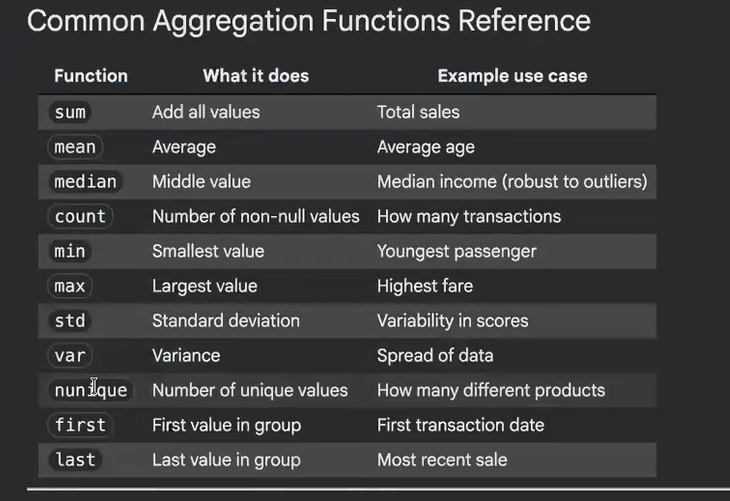